# Plot Monthly Mosaics of Downloaded Basemaps

This notebook stitches downloaded Basemaps quad tiles together to plot a monthly mosaic for Santa Barbara County.

In [2]:
import os
import sys
from glob import glob

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.merge import merge
from tqdm import tqdm

sys.path.append("../utils")

import config

### Import SB county boundary

In [3]:
# Load shapefile for Santa Barbara County
sb_county = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "sb_county_boundary.shp")
)
sb_county = sb_county.to_crs(config.mercator_crs)

### Stitch together quad tiles and plot a monthly mosaic

In [ ]:
def stitch_and_display_rgb(
    basemap_dir, month_year=None, rgb_bands=(0, 1, 2), figsize=(15, 12)
):
    """
    Stitches together quad tiles for a monthly mosaic and displays as RGB.

    Parameters:
    -----------
    basemap_dir : str
        Directory containing the basemap files
    month_year : str or None
        Specific month to process (format: 'YYYY_MM'). If None, lists available months.
    rgb_bands : tuple
        Indices of bands to use for RGB visualization (default: first three bands)
    figsize : tuple
        Size of the output figure

    Returns:
    --------
    fig : matplotlib figure
    mosaic_data : numpy.ndarray
    """
    # List available mosaics if month_year not specified
    available_mosaics = [
        os.path.basename(d)
        for d in glob(os.path.join(basemap_dir, "global_monthly_*_mosaic"))
    ]
    if not month_year:
        print("Available mosaics:")
        for mosaic in available_mosaics:
            print(f"  - {mosaic}")
        return None, None

    # Find the correct mosaic directory
    year, month = month_year.split("_")
    target_dir = os.path.join(basemap_dir, f"global_monthly_{year}_{month}_mosaic")
    if not os.path.exists(target_dir):
        print(f"No mosaic found for {month_year}")
        return None, None

    # Find all quad files
    quads_dir = os.path.join(target_dir, "basemap_quads")
    quad_files = glob(os.path.join(quads_dir, "*_quad.tif"))

    if not quad_files:
        print(f"No quad files found in {quads_dir}")
        return None, None

    print(f"Found {len(quad_files)} quad files")

    # Open files
    src_files_to_merge = []
    for file_path in quad_files:
        try:
            # Only open files that can be read successfully
            with rasterio.open(file_path) as src:
                # Test read a small window to verify file integrity
                test_window = rasterio.windows.Window(0, 0, 1, 1)
                _ = src.read(1, window=test_window)
                # If it passes, add to merge list
                src_files_to_merge.append(rasterio.open(file_path))
        except Exception as e:
            print(f"Skipping {os.path.basename(file_path)}: {str(e)}")

    # Merge the validated files
    try:
        mosaic, out_trans = merge(src_files_to_merge)

        # Close all source files
        for src in src_files_to_merge:
            src.close()

        # Create RGB visualization
        fig, ax = plt.subplots(figsize=figsize)

        if len(rgb_bands) == 3 and mosaic.shape[0] >= 3:
            # Extract RGB bands
            r, g, b = [mosaic[i] for i in rgb_bands]

            # Percentile stretch for better visualization
            rgb = np.zeros((r.shape[0], r.shape[1], 3), dtype=np.float32)

            for i, band in enumerate([r, g, b]):
                valid = band > 0
                if np.any(valid):
                    p_low, p_high = np.percentile(band[valid], [2, 98])
                    if p_high > p_low:
                        rgb[:, :, i] = np.clip((band - p_low) / (p_high - p_low), 0, 1)

            ax.imshow(rgb)
        else:
            # Show single band if RGB not possible
            band = mosaic[min(rgb_bands[0], mosaic.shape[0] - 1)]
            valid = band > 0
            if np.any(valid):
                p_low, p_high = np.percentile(band[valid], [2, 98])
                ax.imshow(band, cmap="viridis", vmin=p_low, vmax=p_high)
            else:
                ax.imshow(band, cmap="viridis")

        ax.set_title(f"Mosaic for {year}-{month}")
        ax.set_axis_off()
        plt.tight_layout()

        return fig, mosaic

    except Exception as e:
        print(f"Merge operation failed: {str(e)}")
        # Clean up open files
        for src in src_files_to_merge:
            src.close()
        return None, None

Found 43 quad files


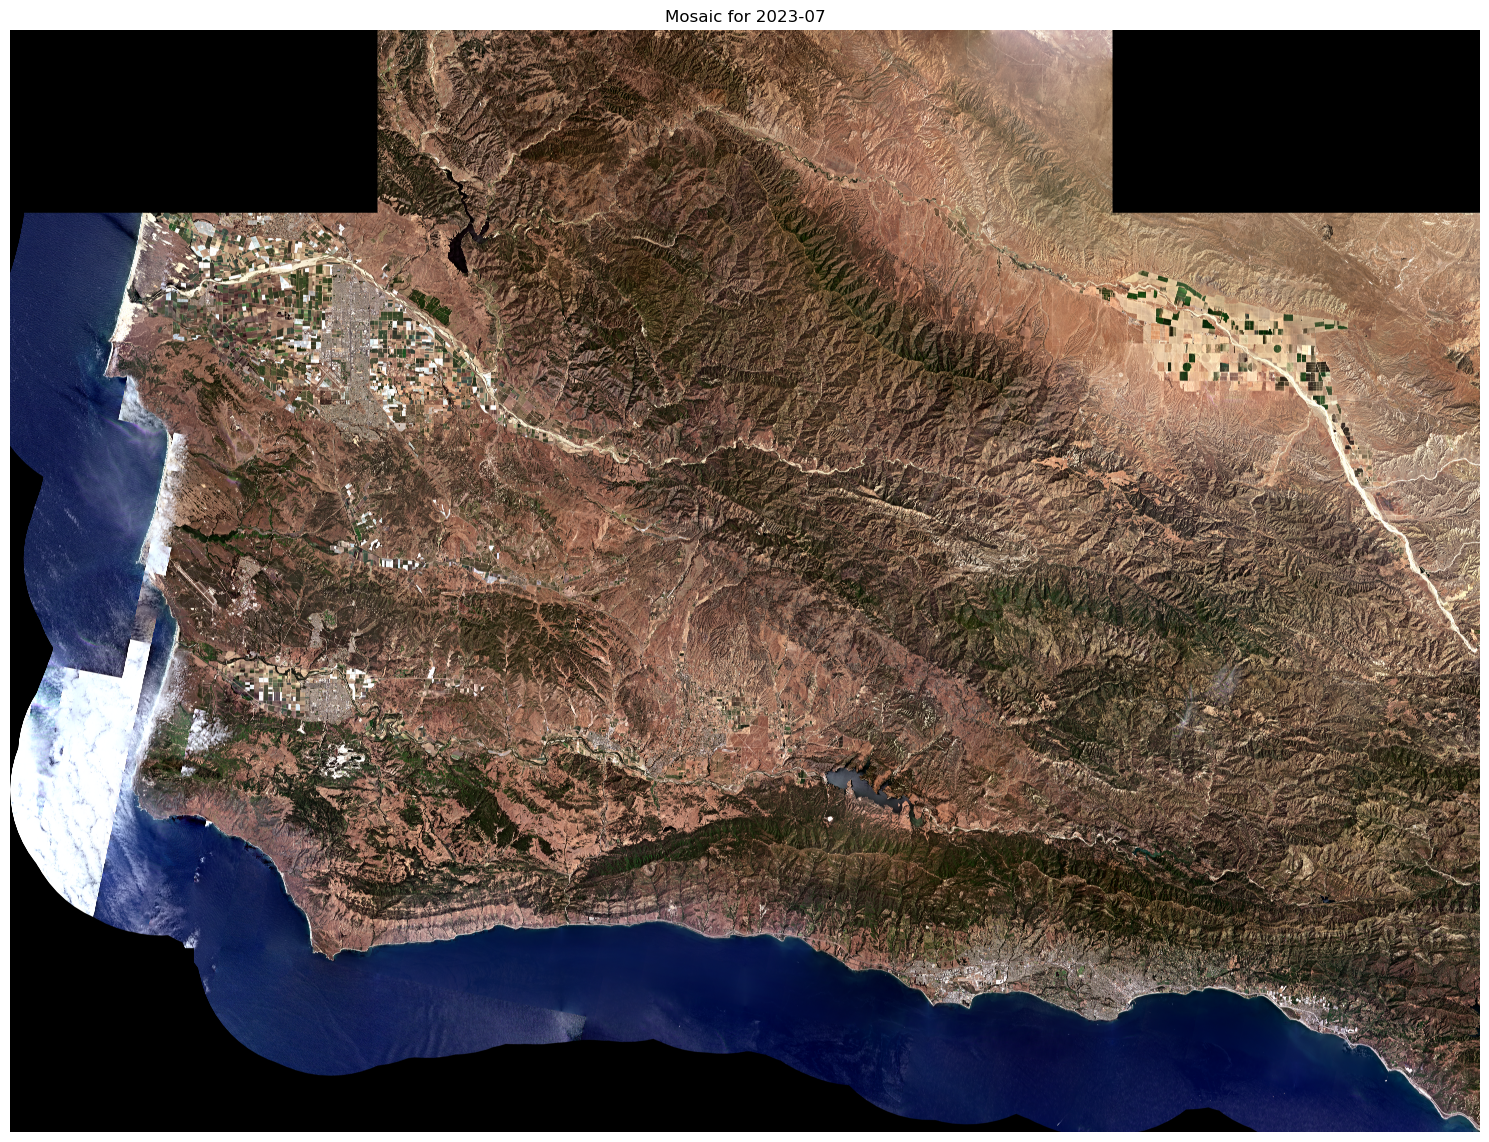

In [ ]:
# Plot monthly RGB mosaic for July 2023
fig, data = stitch_and_display_rgb(config.basemap_dir, month_year="2023_07")